In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import json
import re  # <--- Added for regex cleaning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss, f1_score

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")

print("--- Step 1: Loading Data and Configurations ---")
df = pd.read_csv('application_train_fully_preprocessed.csv')

with open('model_training_features.json', 'r') as f:
    config = json.load(f)

# Assuming your deployment config is in the saved_models folder
with open('../saved_models/deployment_config.json', 'r') as f:
    deploy_config = json.load(f)

features = config['training_features']
target = config['target']
optimal_threshold = deploy_config.get('optimal_threshold', 0.5)

X = df[features]
y = df[target]

# --- THE FIX: Clean feature names to remove special JSON characters ---
X.columns = [re.sub(r'[{}[\],:]', '_', col) for col in X.columns]
# ----------------------------------------------------------------------

print(f"Data Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts(normalize=True) * 100}")

--- Step 1: Loading Data and Configurations ---
Data Shape: (307511, 161)
Target Distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [5]:
print("\n--- Step 2: Re-Training for Learning Curves ---")
# We re-train the model here so we can capture the evaluation history (evals_result)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Using standard parameters (adjust if you used different ones in your tuning phase)
clf = lgb.LGBMClassifier(
    n_estimators=1000,          # High number, let early stopping catch it
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',    # Crucial for 8% minority class
    random_state=42,
    n_jobs=-1
)

# Dictionary to store evaluation results
evals_result = {}

# Fit with early stopping
clf.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_names=['Training', 'Validation'],
    eval_metric=['auc', 'binary_logloss'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.record_evaluation(evals_result)
    ]
)

print("\nModel Training Complete.")


--- Step 2: Re-Training for Learning Curves ---
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021857 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3184
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 153
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning

In [6]:
print("\n--- Step 3: Train vs. Test Metric Gap Analysis ---")

# Get probabilities
y_train_probs = clf.predict_proba(X_train)[:, 1]
y_test_probs = clf.predict_proba(X_test)[:, 1]

# Apply your custom optimal threshold
y_train_preds = (y_train_probs >= optimal_threshold).astype(int)
y_test_preds = (y_test_probs >= optimal_threshold).astype(int)

# Calculate metrics
train_auc = roc_auc_score(y_train, y_train_probs)
test_auc = roc_auc_score(y_test, y_test_probs)
train_logloss = log_loss(y_train, y_train_probs)
test_logloss = log_loss(y_test, y_test_probs)
train_f1 = f1_score(y_train, y_train_preds)
test_f1 = f1_score(y_test, y_test_preds)

print("\n--- PERFORMANCE GAP ---")
print(f"ROC-AUC   -> Train: {train_auc:.4f} | Test: {test_auc:.4f} | Gap: {(train_auc - test_auc):.4f}")
print(f"Log Loss  -> Train: {train_logloss:.4f} | Test: {test_logloss:.4f} | Gap: {(test_logloss - train_logloss):.4f}")
print(f"F1-Score  -> Train: {train_f1:.4f} | Test: {test_f1:.4f} | Gap: {(train_f1 - test_f1):.4f} (at threshold {optimal_threshold})")

print("\nInterpretation:")
print("- A ROC-AUC gap < 0.05 is generally excellent.")
print("- If the Train AUC is > 0.90 and Test AUC is < 0.75, your model is severely overfitted.")


--- Step 3: Train vs. Test Metric Gap Analysis ---

--- PERFORMANCE GAP ---
ROC-AUC   -> Train: 0.7765 | Test: 0.7140 | Gap: 0.0626
Log Loss  -> Train: 0.5805 | Test: 0.5923 | Gap: 0.0118
F1-Score  -> Train: 0.3025 | Test: 0.2602 | Gap: 0.0423 (at threshold 0.58)

Interpretation:
- A ROC-AUC gap < 0.05 is generally excellent.
- If the Train AUC is > 0.90 and Test AUC is < 0.75, your model is severely overfitted.



--- Step 4: Learning Curves Visualization ---


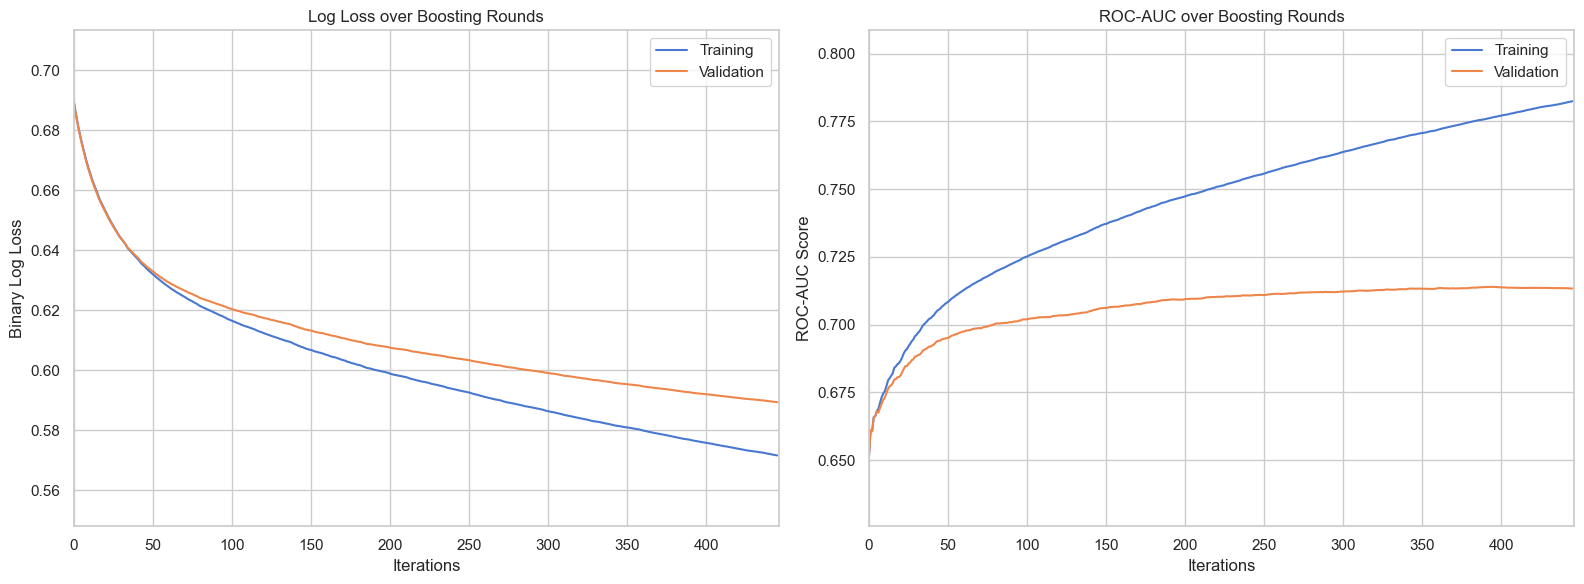

Interpretation:
- Look at the Log Loss chart. Both lines should go down.
- If the Training line continues to drop, but the Validation line flattens out and starts rising again forming a 'U' shape, you are overfitting.
- Early stopping should automatically halt training before the 'U' shape forms.


In [7]:
print("\n--- Step 4: Learning Curves Visualization ---")

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot Log Loss
lgb.plot_metric(evals_result, metric='binary_logloss', ax=ax[0])
ax[0].set_title('Log Loss over Boosting Rounds')
ax[0].set_ylabel('Binary Log Loss')

# Plot AUC
lgb.plot_metric(evals_result, metric='auc', ax=ax[1])
ax[1].set_title('ROC-AUC over Boosting Rounds')
ax[1].set_ylabel('ROC-AUC Score')

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- Look at the Log Loss chart. Both lines should go down.")
print("- If the Training line continues to drop, but the Validation line flattens out and starts rising again forming a 'U' shape, you are overfitting.")
print("- Early stopping should automatically halt training before the 'U' shape forms.")

In [8]:
print("\n--- Step 5: Stratified K-Fold Cross Validation Stability Check ---")
print("Checking if our 80/20 split was a 'lucky' split or if the model generalizes well.")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_auc_scores = []
fold_f1_scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # Train a quick model per fold
    fold_model = lgb.LGBMClassifier(
        learning_rate=0.05, 
        max_depth=6, 
        class_weight='balanced', 
        random_state=42, 
        n_estimators=150, 
        n_jobs=-1
    )
    fold_model.fit(X_tr, y_tr)
    
    # Predict
    val_probs = fold_model.predict_proba(X_val)[:, 1]
    val_preds = (val_probs >= optimal_threshold).astype(int)
    
    # Score
    auc = roc_auc_score(y_val, val_probs)
    f1 = f1_score(y_val, val_preds)
    
    fold_auc_scores.append(auc)
    fold_f1_scores.append(f1)
    print(f"Fold {fold + 1} | AUC: {auc:.4f} | F1: {f1:.4f}")

print("\n--- K-Fold Summary ---")
print(f"Mean AUC: {np.mean(fold_auc_scores):.4f} (Std: +/- {np.std(fold_auc_scores):.4f})")
print(f"Mean F1:  {np.mean(fold_f1_scores):.4f} (Std: +/- {np.std(fold_f1_scores):.4f})")

print("\nInterpretation:")
print("- A Standard Deviation (Std) close to 0 (e.g., < 0.015) means your model is highly stable and NOT overfitting to specific data samples.")
print("- If the AUC fluctuates wildly between folds (e.g., Fold 1: 0.78, Fold 2: 0.65), your model is unstable.")


--- Step 5: Stratified K-Fold Cross Validation Stability Check ---
Checking if our 80/20 split was a 'lucky' split or if the model generalizes well.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021317 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3190
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 154
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Fold 1 | AUC: 0.6997 | F1: 0.2490
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Nu